In [1]:

people = [
    "obama", "osama", "madre", "padre", "dumdum"
]

animals = [
    "kuku", "neko", "resta", "kaka",
    "chichi", "kawkaw"
]

plural_animals = {
    "kuku": "kukun",
    "neko": "nekon",
    "resta": "restan",
    "kaka": "kakan",
    "chichi": "chichin",
    "kawkaw": "kawkawn"
}

objects = [
    "vomi", "kafka", "ghar"
]

places = [
    "femi", "damar"
]

# TODO : fix the collision issue with fira(red) and fira(star)(maybe)

nature = [

    "luma", "fira"
]

nouns = people + animals + objects + places + nature

adjectives = [
    "fira", "boku", "sena", "moro",
    "leni", "vaku", "desa", "roni",
    "kema", "zeli", "pira", "nemo",
    "jaku", "henu", "bora", "tenu",
    "fomi", "yera", "dani", "loku"
]

det = ["ta", "na"]


motion = [
    "bhago", "jojo", "davi",
    "nexo", "snan"
]

plural_motion = {
    "bhago": "bhagos",
    "jojo": "jojos",
    "davi": "davis",
    "nexo": "nexos",
    "snan": "snans",
    "icarus": "icaruss"
}

fly = [
    "icarus"
]

perception = [
    "perv",
    "rime"
]

manipulation = [
    "paku",
    "soro",
    "sisy",
    "loti",
    "bobder",
    "fenu",
    "zari"
]

consumption = [
    "yumyum"
]

fly_subjects = [
    "chichi",
    "kawkaw"
]

plural_special = {
    "yumyum": "yumyums",
    "perv": "pervs",
    "rime": "rimes",
    "paku": "pakus",
    "soro": "soros",
    "loti": "lotis",
    "fenu": "fenus",
    "zari": "zaris",
    "sisy": "sisys",
    "bobder": "bobders"
}

In [2]:
word_category = {}

for w in people:
    word_category[w] = "human"

for w in animals:
    word_category[w] = "animal"

for w in objects:
    word_category[w] = "object"

for w in places:
    word_category[w] = "place"

for w in adjectives:
    word_category[w] = "adjective"

In [3]:
import torch
with open('../data/langv2.txt', 'r', encoding = 'utf-8') as f:
    text = f.read()

torch.manual_seed(1337)


tokens = []
for line in text.splitlines():
    tokens.append("<BOS>")
    tokens.extend(line.split())
    tokens.append("<EOS>")

chars = sorted(list(set(tokens)))
vocab_size = len(chars)
stoi = {w:i for i, w in enumerate(chars)}
itos = {i:w for i, w in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s.split()]
decode = lambda l: ' '.join([itos[i] for i in l])

data = torch.tensor(
    [stoi[t] for t in tokens],
    dtype=torch.long
)

In [4]:

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity


def nearest_neighbors(word, model, k=10):
    emb = model.token_embedding.weight.detach().cpu().numpy()
    sim = cosine_similarity(emb)

    idx = stoi[word]

    neighbors = sim[idx].argsort()[::-1][1:k+1]

    return [(itos[i], sim[idx, i]) for i in neighbors]

In [5]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from sauce.experi import BigramModel

model = BigramModel()

In [6]:
ckpt = torch.load('../checkpoints/langv2e1/ckpt_1999.pt')
model.load_state_dict(ckpt['model_state_dict'])

<All keys matched successfully>

In [7]:
nearest_neighbors("obama", model, k=10)

[('yumyums', np.float32(0.29024032)),
 ('kaka', np.float32(0.26300701)),
 ('icaruss', np.float32(0.24126978)),
 ('<BOS>', np.float32(0.20531206)),
 ('na', np.float32(0.18890715)),
 ('vaku', np.float32(0.17608558)),
 ('tenu', np.float32(0.14071245)),
 ('paku', np.float32(0.14028828)),
 ('snan', np.float32(0.12648278)),
 ('nemo', np.float32(0.10394818))]

In [8]:
def neighbor_purity(word, model, k=10):
    if word not in word_category:
        return None

    target_category = word_category[word]

    neighbors = nearest_neighbors(word, model, k)

    same = 0

    for neighbor, _ in neighbors:
        if word_category.get(neighbor) == target_category:
            same += 1

    return same / k

In [9]:
neighbor_purity('chichi', model)

0.2

In [10]:
def average_purity(model, words, k=10):
    scores = []

    for word in words:
        score = neighbor_purity(word, model, k)

        if score is not None:
            scores.append(score)

    return np.mean(scores)

In [11]:
semantic_words = people + animals + objects + places

print(
    average_purity(
        model,
        semantic_words,
        k=5
    )
)

0.1


In [12]:
checkpoints = [
    100,
    250,
    500,
    1000,
    1250,
    1500,
    1999
]
purities = []

for step in checkpoints:

    ckpt = torch.load(
        f"../checkpoints/langv2e1/ckpt_{step}.pt",
    )

    model.load_state_dict(
        ckpt["model_state_dict"]
    )

    score = average_purity(
        model,
        semantic_words,
        k=5
    )

    purities.append(score)

    print(step, score)

100 0.08750000000000001
250 0.08750000000000001
500 0.1
1000 0.1
1250 0.1
1500 0.1
1999 0.1


In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
sentence = "ta leni osama soro ta yera resta"
ids = encode(sentence)

x = torch.tensor(
    [ids],
    dtype=torch.long,
    device=device
)


In [15]:
ids

[58, 32, 45, 57, 58, 62, 50]

In [28]:
ckpt = torch.load('../checkpoints/langv2e1/ckpt_1999.pt')
model.load_state_dict(ckpt['model_state_dict'])

<All keys matched successfully>

In [29]:
model.to(device)
model.eval()
with torch.no_grad():
    model(x)

In [30]:
attn = (model.blocks[0]
         .sa_head
         .heads[0]
         .last_attention[0])
attn

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6887, 0.3113, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0878, 0.3997, 0.5125, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.8534, 0.0487, 0.0307, 0.0671, 0.0000, 0.0000, 0.0000],
        [0.0367, 0.5764, 0.0176, 0.0306, 0.3386, 0.0000, 0.0000],
        [0.1295, 0.0241, 0.7788, 0.0145, 0.0378, 0.0152, 0.0000],
        [0.0152, 0.0121, 0.0276, 0.7414, 0.0368, 0.1472, 0.0196]])

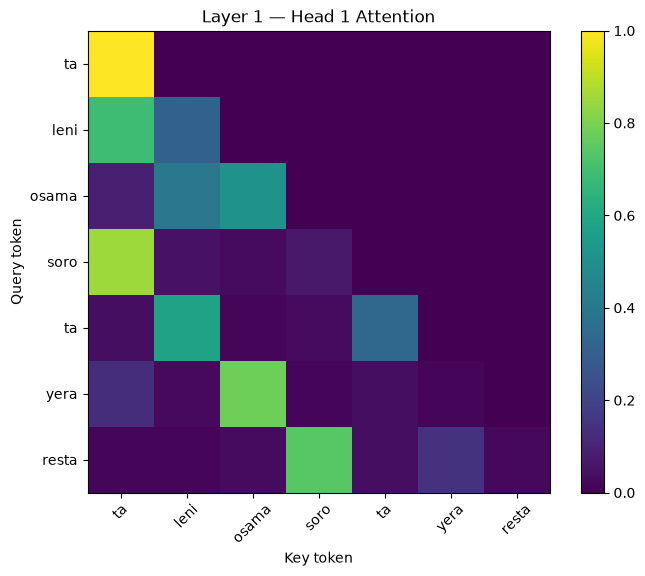

In [31]:
import matplotlib.pyplot as plt
tokens = sentence.split()

plt.figure(figsize=(8,6))

plt.imshow(attn.numpy())

plt.xticks(
    range(len(tokens)),
    tokens,
    rotation=45
)

plt.yticks(
    range(len(tokens)),
    tokens
)

plt.colorbar()
plt.xlabel("Key token")
plt.ylabel("Query token")
plt.title("Layer 1 — Head 1 Attention")

plt.show()

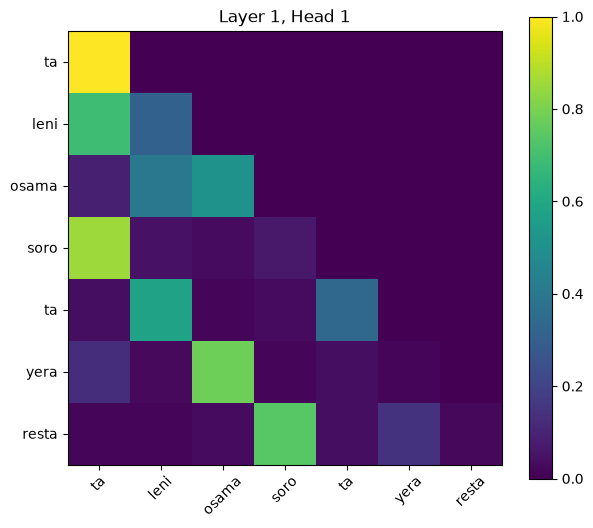

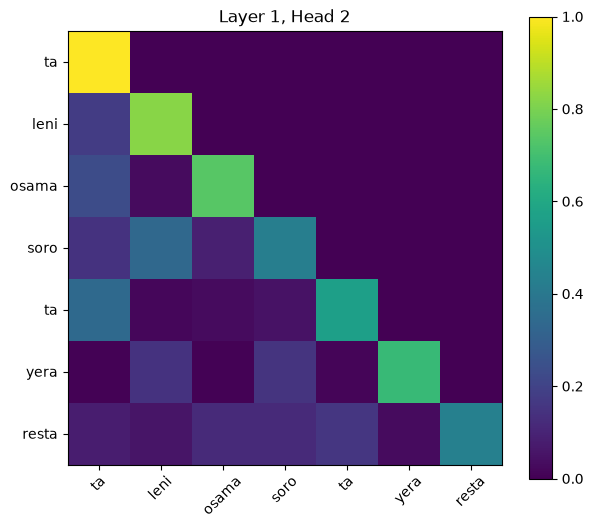

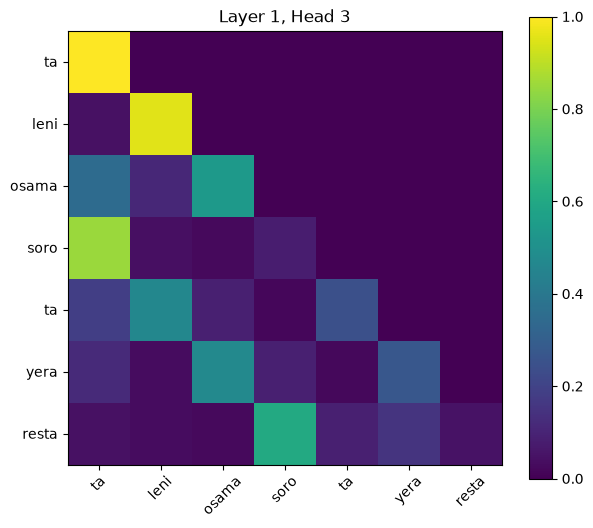

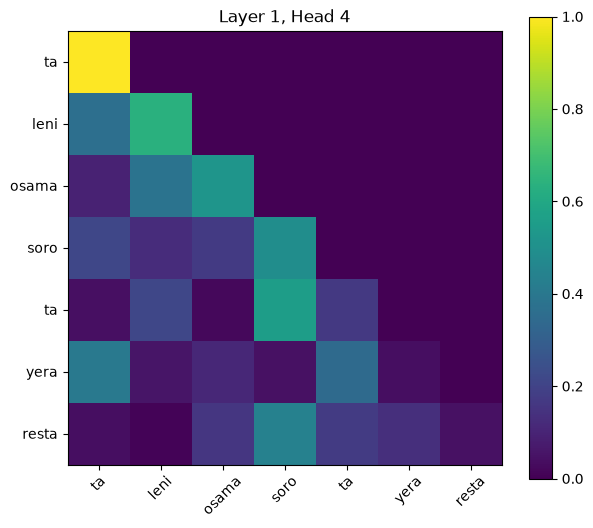

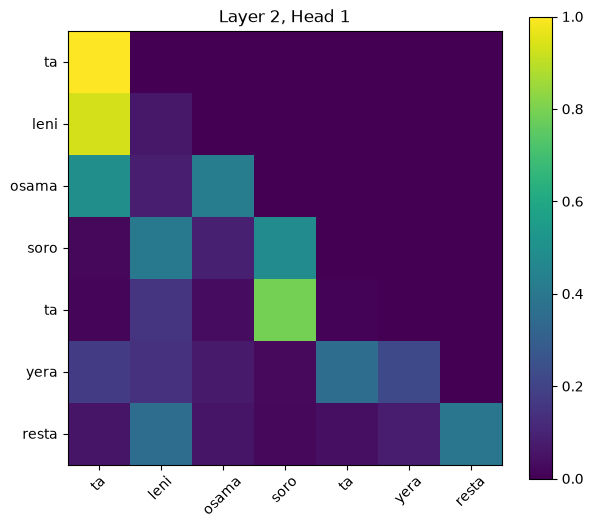

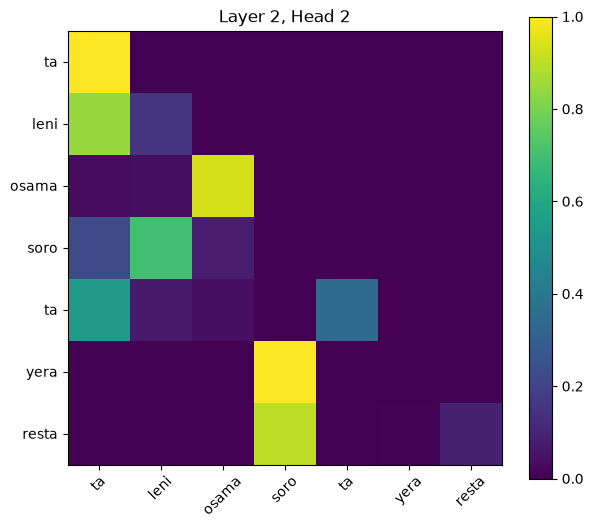

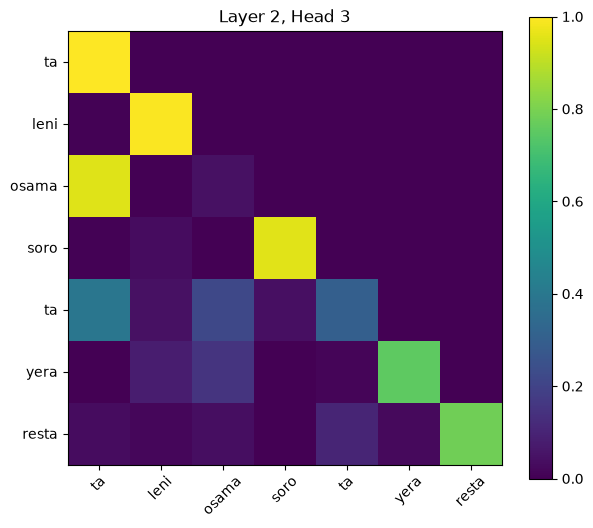

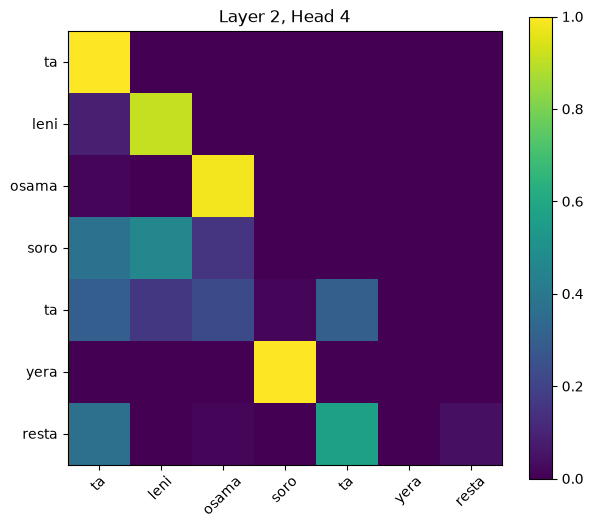

In [32]:
for layer_idx, block in enumerate(model.blocks):
    for head_idx, head in enumerate(block.sa_head.heads):
        attn = head.last_attention[0].numpy()
        plt.figure(figsize=(7,6))
        plt.imshow(attn)
        plt.xticks(
            range(len(tokens)),
            tokens,
            rotation=45
        )
        plt.yticks(
            range(len(tokens)),
            tokens
        )
        plt.colorbar()

        plt.title(
            f"Layer {layer_idx+1}, Head {head_idx+1}"
        )
        plt.savefig(f'../plots/osama-resta-{layer_idx+1}-{head_idx+1}.png')
        

In [33]:
sent1 = "ta leni osama soro ta yera resta"
x1 = torch.tensor(
    [encode(sent1)],
    device=device
)
with torch.no_grad():
    model(x1)
h1 = model.last_hidden[0].clone()

sent2 = "ta yera resta soro ta leni osama"
x2 = torch.tensor(
    [encode(sent2)],
    device=device
)
with torch.no_grad():
    model(x2)
h2 = model.last_hidden[0].clone()


In [34]:
print(sent1.split())
print(sent2.split())

['ta', 'leni', 'osama', 'soro', 'ta', 'yera', 'resta']
['ta', 'yera', 'resta', 'soro', 'ta', 'leni', 'osama']


In [35]:
osama_subject = h1[2]
osama_object = h2[6]

In [36]:
import torch.nn.functional as F

sim = F.cosine_similarity(
    osama_subject.unsqueeze(0),
    osama_object.unsqueeze(0)
)

print(sim.item())

0.7182456254959106


In [37]:

attn = head.last_attention[0]
entropy = -(
    attn * torch.log(attn + 1e-9)
).sum(dim=-1)

print(entropy)
mean_entropy = entropy.mean().item()
mean_entropy

tensor([-0.0000, 0.4474, 0.3321, 1.0381, 1.3799, 0.0488, 0.8691])


0.587906539440155

In [38]:
sentences = []

for _ in range(500):
    context = torch.tensor(
        [[stoi["<BOS>"]]],
        device=device
    )

    out = model.generate(
        context,
        max_new_tokens=20
    )

    sentence = decode(out[0].tolist())

    sentences.append(sentence)

In [39]:
sentences

['<BOS> ta moro obama rime ta pira kafka',
 '<BOS> na moro chichi yumyum na nemo kawkaw',
 '<BOS> na tenu obama rime ta leni kafka',
 '<BOS> ta henu dumdum loti ta vaku kafka',
 '<BOS> na yera kawkawn icaruss',
 '<BOS> na kema femi',
 '<BOS> na boku madre loti na fira kafka',
 '<BOS> ta vaku kawkaw icarus',
 '<BOS> ta boku kaka davi',
 '<BOS> na moro neko yumyum ta tenu kaka',
 '<BOS> ta moro dumdum rime na henu kafka',
 '<BOS> na tenu madre yumyum ta nemo kawkaw',
 '<BOS> ta vaku dumdum yumyum ta zeli vomi',
 '<BOS> na desa resta bhago',
 '<BOS> na jaku dumdum rime na henu kafka',
 '<BOS> na kema kawkawn icaruss',
 '<BOS> na pira chichi icarus',
 '<BOS> na bora neko perv na yera yumyums ta jaku restan',
 '<BOS> na pira neko paku ta boku resta',
 '<BOS> ta loku dumdum loti na vaku kafka',
 '<BOS> na jaku nekon yumyums ta vaku resta',
 '<BOS> ta loku obama loti na yera kafka',
 '<BOS> ta fira dumdum soro na fomi obama',
 '<BOS> ta moro ghar',
 '<BOS> ta pira osama paku na vaku resta',
 

In [40]:
hidden_vectors = []
labels = []

for sentence in sentences:

    words = sentence.split()

    ids = torch.tensor(
        [encode(sentence)],
        device=device
    )

    with torch.no_grad():
        model(ids)

    hidden = model.last_hidden[0]

    for pos, word in enumerate(words):

        if word in people:
            hidden_vectors.append(
                hidden[pos].numpy()
            )
            labels.append("human")

        elif word in animals:
            hidden_vectors.append(
                hidden[pos].numpy()
            )
            labels.append("animal")

        elif word in objects:
            hidden_vectors.append(
                hidden[pos].numpy()
            )
            labels.append("object")


In [43]:
len(hidden_vectors)

798

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

X = np.array(hidden_vectors)
X.shape


pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

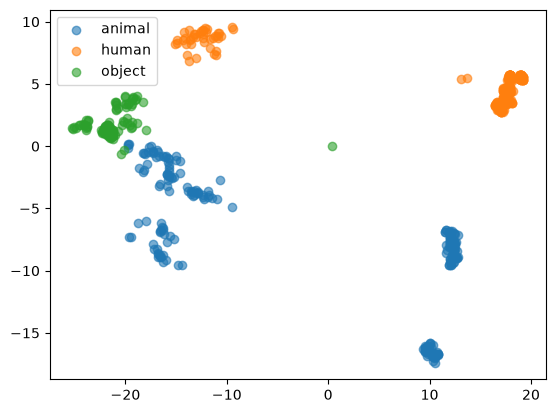

In [47]:
import matplotlib.pyplot as plt

for label in set(labels):

    idx = [
        i
        for i,l in enumerate(labels)
        if l == label
    ]

    plt.scatter(
        X_2d[idx,0],
        X_2d[idx,1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.show()